## Boolean networks <a class="anchor" id="bn"></a>

In [75]:
# --------------
# Notebook setup
# --------------

%matplotlib inline

# Standard library

from itertools import combinations
from pathlib import Path

# Third-party packages

import mpbn
import bonesistools as bt

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from IPython.display import display

# Global display and plotting settings

pd.set_option("future.no_silent_downcasting", True)
bt.sct.pl.set_default_params()

plt.rcParams["xtick.labelsize"] = 16
plt.rcParams["ytick.labelsize"] = 16
plt.rcParams["legend.fontsize"] = 16

# Case-study directories

def find_project_root(start=None, markers=(".git", "apl")):
    """Locate the case-study root directory from any notebook location."""

    start = Path.cwd() if start is None else Path(start).resolve()

    for path in (start, *start.parents):
        if all((path / marker).exists() for marker in markers):
            return path

    raise FileNotFoundError(
        f"Could not find project root from {start} using markers {markers}"
    )

PROJECT_DIR = find_project_root()
APL_DIR = PROJECT_DIR / "apl"

DATA_DIR = APL_DIR / "data"
FIGURE_DIR = APL_DIR / "figures"
GO_DIR = PROJECT_DIR / "data" / "public" / "go"

FIGURE_DIR.mkdir(exist_ok=True)

# Biological settings

conditions = ["ctrl", "treated"]
labels_order = ["Prom1", "Prom2", "Rep", "Cycl", "Neu", "Alt"]

# Notebook helper functions

def display_counts(counts, index_name="item", count_name="n"):
    """Display a compact count summary."""

    summary = pd.DataFrame(
        [(name, count) for name, count in counts.items()],
        columns=[index_name, count_name],
    )
    display(summary.style.hide(axis="index"))

def split_macrostate(name):
    condition, macrostate = name.split("_", 1)
    return condition, macrostate

def fixed_shared_components(hc1, hc2):
    """Return features fixed in both hypercubes."""

    return [
        component
        for component in hc1.components & hc2.components
        if hc1[component].is_fixed and hc2[component].is_fixed
    ]

def hypercube_distance(hc1, hc2):
    """Count mismatching binarised features between two hypercubes."""

    return sum(
        hc1[component] != hc2[component]
        for component in fixed_shared_components(hc1, hc2)
    )

def hypercube_maximum(hc1, hc2):
    """Count jointly defined features between two hypercubes."""

    return len(fixed_shared_components(hc1, hc2))

def pairwise_hypercube_matrix(hypercubes, metric):
    """Build a symmetric pairwise matrix from a hypercube metric."""

    names = list(hypercubes)
    matrix = pd.DataFrame(np.nan, index=names, columns=names, dtype=float)

    for name in names:
        matrix.at[name, name] = metric(hypercubes[name], hypercubes[name])

    for name1, name2 in combinations(names, 2):
        value = metric(hypercubes[name1], hypercubes[name2])
        matrix.at[name1, name2] = value
        matrix.at[name2, name1] = value

    return matrix

def order_macrostate_matrix(matrix):
    """Order a macrostate matrix by condition and biological label."""

    matrix = matrix.copy()
    matrix.index = pd.MultiIndex.from_tuples(
        [split_macrostate(name) for name in matrix.index],
    )
    matrix.columns = pd.MultiIndex.from_tuples(
        [split_macrostate(name) for name in matrix.columns],
    )

    ordered_index = [
        (condition, label)
        for condition in conditions
        for label in labels_order
        if (condition, label) in matrix.index
    ]

    return matrix.loc[ordered_index, ordered_index].rename_axis(
        index=[None, None],
        columns=[None, None],
    )

def upper_triangle(matrix):
    """Hide the lower triangle of a square matrix."""

    mask = np.tril(np.ones(matrix.shape, dtype=bool), k=-1)
    return matrix.mask(mask)



## Data overview <a class="anchor" id="data"></a>

### Load Boolean Networks

Two objects generated by scBOLT are loaded:

* partially binarised macrostates;
* subset-minimal Boolean networks;

In [76]:
bns = bt.bpy.bn.read_bnet_directory(
    DATA_DIR / "bn" / "submin",
    recursive=True,
)
components = bns.components

mstate_hypercubes = bt.bpy.ba.read_hypercubes(
    DATA_DIR / "mstates_bin.csv",
    orientation="rows",
)
features = set().union(*(hc.components for hc in mstate_hypercubes.values()))

mstate_hypercubes = {
    name: hc.drop(set(hc.components) - set(components))
    for name, hc in mstate_hypercubes.items()
}

#mstates_df = pd.read_csv(
#    DATA_DIR / "mstates_bin.csv",
#    index_col=0
#).fillna("*").replace("-", "_")
#features = set(mstates_df.columns)
#mstates_df = mstates_df[[component for component in components if component in mstates_df.columns]]

display_counts(
    {
        "macrostates": len(mstate_hypercubes),
        "boolean networks": len(bns),
        "components": len(components),
    },
    index_name="",
)

components_in_bin_and_bn = components.intersection(features)
components_in_bn_notin_bin = components.difference(features)

component_summary = display_counts(
    {
        "in binarisation": len(features),
        "in BNs": len(components),
        "intersection": len(components & features),
        "difference": len(components - features),
    },
    index_name="",
    count_name="n_components",
)


,n
macrostates,9
boolean networks,1000
components,193


,n_components
in binarisation,3228
in BNs,193
intersection,167
difference,26


### Structural property overview

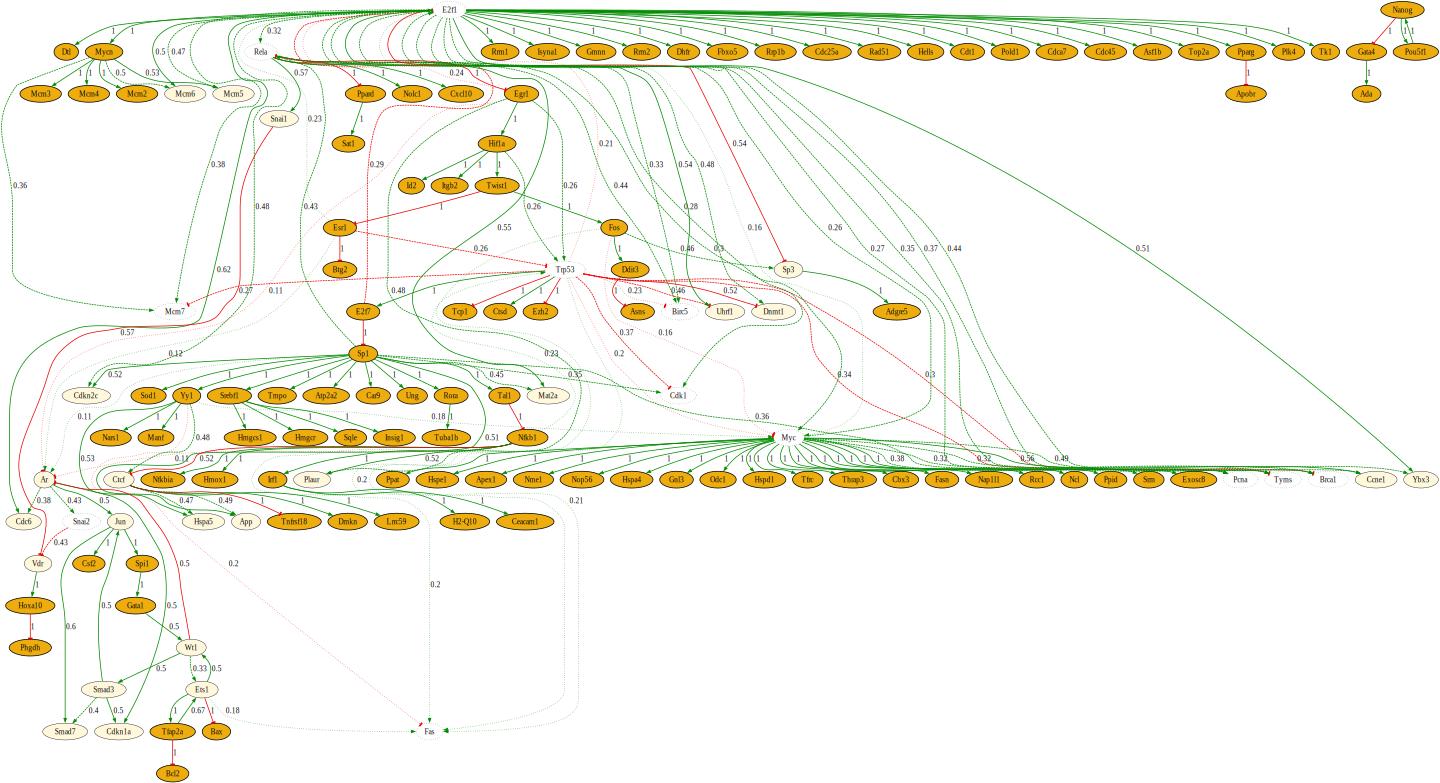

In [77]:
ig = bt.bpy.ig.AggregatedInfluenceGraph.from_boolean_networks(bns)

ig.show(
    remove_isolated_nodes = True,
    edge_label="frequency",
    ratio="compress",
    size="20,30!",
    overlap="prism",
    sep="+0",
    esep="+0",
    K="0.35",
    ranksep="0.6",
    pack="true",
    rankdir="TB",
    splines="curve",
    node_style=lambda data: {
        **bt.bpy.pl.stability_node_style(data),
        "fontsize": "20",
    },
    edge_style=lambda freq: {
        **bt.bpy.pl.ratio_edge_style(freq),
        "fontsize": "20",
    },
)

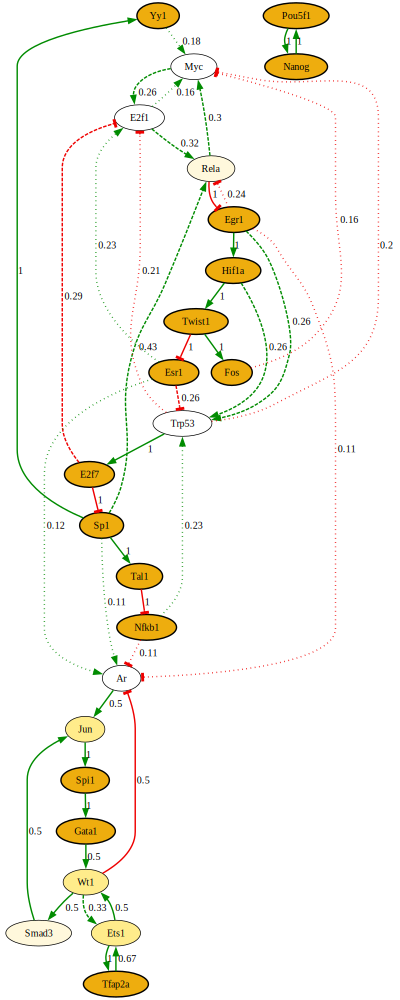

In [79]:
ig.show(
    collapse = "both",
    remove_isolated_nodes = True,
    edge_label="frequency",
    node_style = "count",
    protect_feedback_nodes = True,
    include_singleton_selfloops = False,
    min_frequency = 0,
    program = "dot",
    ratio="compress",
    rankdir="TB",
    splines="curve",
    ranksep="0.25",
    pack="true",
    sep="+0",
    esep="+0",
    K="0.35",
    overlap="prism",
    width="400px",
    height="1000px",
)

### 2. Pairwise macrostate distances <a class="anchor" id="distances"></a>

Pairwise distance matrix between macrostates based on the selected Boolean-network components. Each distance is the number of components that are defined in both macrostates and assigned different Boolean values. The corresponding maximum observable distance is the number of components defined in both macrostates, independently of whether their values match or differ. Pairwise similarity can therefore be computed as the maximum observable distance minus the observed distance.

In [84]:
distance = order_macrostate_matrix(
    pairwise_hypercube_matrix(mstate_hypercubes, hypercube_distance),
)
maximum = order_macrostate_matrix(
    pairwise_hypercube_matrix(mstate_hypercubes, hypercube_maximum),
)

distance_upper = upper_triangle(distance)
maximum_upper = upper_triangle(maximum)

display(
    distance_upper.style
    .set_caption("Pairwise macrostate distances")
    .format("{:.0f}", na_rep="")
)
display(
    maximum_upper.style
    .set_caption("Jointly binarised genes per macrostate pair")
    .format("{:.0f}", na_rep="")
)

In [ ]:

def get_states(
    file,
    init_state_names=None,
    final_state_names=None,
    keys=None,
):
    """
    Load macrostate-associated Boolean states and selected hypercubes.

    Parameters
    ----------
    file: str
        CSV file containing genes in rows and state names in columns.
    init_state_names: list, optional
        State names to convert into initial-state hypercubes.
    final_state_names: list, optional
        State names to convert into terminal-state hypercubes.
    keys: list, optional
        Optional subset of row names to keep.

    Returns
    -------
    tuple
        State dataframe, initial-state hypercubes, and terminal-state
        hypercubes.
    """

    states = pd.read_csv(file, index_col=0).replace("-", "_")
    if keys is not None:
        states.drop(index=set(states.index) - set(keys), inplace=True)
    init_states = {state_name: bt.bpy.Hypercube(states.loc[:, state_name].to_dict()) for state_name in init_state_names} if init_state_names is not None else None
    final_states = {state_name: bt.bpy.Hypercube(states.loc[:, state_name].to_dict()) for state_name in final_state_names} if final_state_names is not None else None
    return states, init_states, final_states

states_bin = {}
states_bin["states"] = pd.read_csv("data/interest/bin/bin_macrostates.csv", index_col=0).fillna("*").replace("-", "_").transpose()

bn_one = mpbn.MPBooleanNetwork.load("data/interest/bn/one/one.bnet")
states_one = {}
states_one["states"], states_one["initial"], states_one["terminal"] = get_states(
    "data/interest/bn/one/metastates.csv",
    init_state_names=["ctrl_promyelocytes", "treated_promyelocytes"],
    final_state_names=["ctrl_proliferation", "ctrl_apoptosis", "ctrl_differentiation", "treated_proliferation", "treated_differentiation"]
)

components = set(states_one["states"].index)
components_in_bin_and_bn = components.intersection(set(states_bin["states"].index))
components_in_bn_notin_bin = components.difference(set(states_bin["states"].index))

component_summary = display_counts(
    {
        "BN components": len(components),
        "components in macrostates and BN": len(components_in_bin_and_bn),
        "components in BN only": len(components_in_bn_notin_bin),
    },
    index_name="summary",
    count_name="n_components",
)

if components_in_bn_notin_bin:
    display(pd.Series(sorted(components_in_bn_notin_bin), name="components in BN only"))

states_bin["states"] = pd.concat([states_bin["states"], pd.DataFrame(data="*", index=list(components_in_bn_notin_bin), columns=states_bin["states"].columns)], axis=0)
states_bin["states"].rename(columns={
    "ctrl_Prom1": "ctrl_promyelocytes",
    "ctrl_Prom2": "ctrl_intermediary",
    "ctrl_Rep": "ctrl_proliferation",
    "ctrl_Alt": "ctrl_altered",
    "ctrl_Neu": "ctrl_differentiation",
    "treated_Prom1": "treated_promyelocytes",
    "treated_Prom2": "treated_intermediary",
    "treated_Rep": "treated_proliferation",
    "treated_Neu": "treated_differentiation",
}, inplace=True)
states_bin["states"] = states_bin["states"].loc[states_one["states"].index, states_one["states"].columns]
states_bin["initial"] = {state_name: bt.bpy.Hypercube(states_bin["states"].loc[:,state_name].to_dict()) for state_name in ["ctrl_promyelocytes", "treated_promyelocytes"]}
states_bin["terminal"] = {state_name: bt.bpy.Hypercube(states_bin["states"].loc[:,state_name].to_dict()) for state_name in ["ctrl_proliferation", "ctrl_apoptosis", "ctrl_differentiation", "treated_proliferation", "treated_differentiation"]}

display(states_one["states"].transpose())
display(states_bin["states"].transpose())

In [ ]:
states_bin = {}
states_bin["states"] = pd.read_csv("data/interest/bin/bin_macrostates.csv", index_col=0).fillna("*").replace("-", "_").transpose()

bn_one = mpbn.MPBooleanNetwork.load("data/interest/bn/one/one.bnet")
states_one = {}
states_one["states"], states_one["initial"], states_one["terminal"] = get_states(
    "data/interest/bn/one/metastates.csv",
    init_state_names=["ctrl_promyelocytes", "treated_promyelocytes"],
    final_state_names=["ctrl_proliferation", "ctrl_apoptosis", "ctrl_differentiation", "treated_proliferation", "treated_differentiation"]
)

components = set(states_one["states"].index)
components_in_bin_and_bn = components.intersection(set(states_bin["states"].index))
components_in_bn_notin_bin = components.difference(set(states_bin["states"].index))

component_summary = display_counts(
    {
        "BN components": len(components),
        "components in macrostates and BN": len(components_in_bin_and_bn),
        "components in BN only": len(components_in_bn_notin_bin),
    },
    index_name="summary",
    count_name="n_components",
)

if components_in_bn_notin_bin:
    display(pd.Series(sorted(components_in_bn_notin_bin), name="components in BN only"))

states_bin["states"] = pd.concat([states_bin["states"], pd.DataFrame(data="*", index=list(components_in_bn_notin_bin), columns=states_bin["states"].columns)], axis=0)
states_bin["states"].rename(columns={
    "ctrl_Prom1": "ctrl_promyelocytes",
    "ctrl_Prom2": "ctrl_intermediary",
    "ctrl_Rep": "ctrl_proliferation",
    "ctrl_Alt": "ctrl_altered",
    "ctrl_Neu": "ctrl_differentiation",
    "treated_Prom1": "treated_promyelocytes",
    "treated_Prom2": "treated_intermediary",
    "treated_Rep": "treated_proliferation",
    "treated_Neu": "treated_differentiation",
}, inplace=True)
states_bin["states"] = states_bin["states"].loc[states_one["states"].index, states_one["states"].columns]
states_bin["initial"] = {state_name: bt.bpy.Hypercube(states_bin["states"].loc[:,state_name].to_dict()) for state_name in ["ctrl_promyelocytes", "treated_promyelocytes"]}
states_bin["terminal"] = {state_name: bt.bpy.Hypercube(states_bin["states"].loc[:,state_name].to_dict()) for state_name in ["ctrl_proliferation", "ctrl_apoptosis", "ctrl_differentiation", "treated_proliferation", "treated_differentiation"]}

display(states_one["states"].transpose())
display(states_bin["states"].transpose())

In [ ]:
attractors = bt.bpy.HypercubeCollection(list(bn_one.attractors()))
attractor_summary = display_counts(
    {
        "attractors": len(attractors),
        "fixed points": len(attractors.get_fixed_points()),
    },
    index_name="summary",
    count_name="n",
)

display(pd.DataFrame.from_dict(attractors))

### 3. Subset minimal BNs <a class="anchor" id="minimal"></a>

In [ ]:
import math

import matplotlib as mpl
mpl.rcParams["figure.dpi"] = 60

bns = []
cfgs = []

macrostates = pd.read_csv("data/interest/bin/bin_macrostates.csv", index_col=0).transpose()
for c in set(components) - set(macrostates.index):
    macrostates.loc[c] = pd.Series()
macrostates = macrostates.loc[components,:].replace(math.nan, "*").to_dict()
for k, v in macrostates.items():
    macrostates[k] = bt.bpy.Hypercube(v)

configuration_space = dict()
for condition, macrostate in macrostates.items():
    to_remove = []
    for k, v in macrostate.items():
        if isinstance(v, str):
            to_remove.append(k)

    configuration_space[condition] = {
        "n_free_components": len(to_remove),
        "n_configurations": 2 ** len(to_remove),
    }
    for k in to_remove:
        del macrostate[k]

configuration_space = pd.DataFrame.from_dict(configuration_space, orient="index")
configuration_space.index.name = "macrostate"
display(configuration_space)

for i in range(100):
    bns.append(mpbn.MPBooleanNetwork.load(f"data/interest/bn/sub/{i}/sub.bnet"))
    cfg = pd.read_csv(f"data/interest/bn/sub/{i}/metastates.csv", index_col=0).to_dict()
    for k, v in cfg.items():
        cfg[k] = bt.bpy.Hypercube(v)
    cfgs.append(cfg)
    del cfg

bns = bt.bpy.BooleanNetworkEnsemble(bns=bns)
components = list(bns.get_components())

attractor_number = pd.Series([len(list(bn.attractors())) for bn in bns]).value_counts().to_dict()
k, v = [], []
for n in sorted(attractor_number.keys()):
    k.append(n)
    v.append(attractor_number[n])
fig, ax = plt.subplots(nrows=1, ncols=1)
plt.bar(k, v, width=1, facecolor=bt.sct.pl.get_color("pink"), edgecolor=bt.sct.pl.get_color("red"), linewidth=1.5)
plt.xlim([k[0]-0.5, k[-1]+0.6])
plt.ylim(0, max(v)+1)
plt.title("From any configurations")
plt.show()
plt.close()

for name in ["ctrl_promyelocytes", "treated_promyelocytes"]:
    attractor_number = pd.Series([len(list(bn.attractors(reachable_from=cfg[name]))) for cfg, bn in zip(cfgs, bns)]).value_counts().to_dict()
    k, v = [], []
    for n in sorted(attractor_number.keys()):
        k.append(n)
        v.append(attractor_number[n])
    fig, ax = plt.subplots(nrows=1, ncols=1)
    plt.bar(k, v, width=1, facecolor=bt.sct.pl.get_color("pink"), edgecolor=bt.sct.pl.get_color("red"), linewidth=1.5)
    plt.xlim([k[0]-0.5, k[-1]+0.6])
    plt.ylim(0, max(v)+1)
    plt.xticks(k)
    plt.title(f"From configuration {name}")
    plt.show()
    plt.close()

for name in ["ctrl_prom1", "treated_prom1"]:
    attractor_number = pd.Series([len(list(bn.attractors(reachable_from=macrostates[name]))) for bn in bns]).value_counts().to_dict()
    k, v = [], []
    for n in sorted(attractor_number.keys()):
        k.append(n)
        v.append(attractor_number[n])
    fig, ax = plt.subplots(nrows=1, ncols=1)
    plt.bar(k, v, width=1, facecolor=bt.sct.pl.get_color("pink"), edgecolor=bt.sct.pl.get_color("red"), linewidth=1.5)
    plt.xlim([k[0]-0.5, k[-1]+0.6])
    plt.ylim(0, max(v)+1)
    plt.xticks(k)
    plt.title(f"From macrostate {name}")
    plt.show()
    plt.close()

In [ ]:
macrostate_size_summary = display_counts(
    {name: len(macrostate) for name, macrostate in macrostates.items()},
    index_name="macrostate",
    count_name="n_defined_components",
)
